# Variance of a Discrete Random Variable

Let $X$ be a discrete random variable with mean $\mu = E[X]$.

**Variance** $\sigma^2$ measures the **spread** of $X$ around its mean — it is the probability-weighted average of the squared deviations from $\mu$:

$$\boxed{\sigma^2 = E[(X-\mu)^2] = \sum_{i=1}^{N_x} (x_i - \mu)^2\; P(X = x_i) = \sum_X (X - \mu)^2\, P(X)}$$

**Standard deviation** $\sigma$ is in the same units as $X$:

$$\boxed{\sigma = \sqrt{\text{Variance}} = \sqrt{E[(X-\mu)^2]}}$$

- Variance is the **second-order statistical moment** of $X$
- It measures the squared deviation of the random variable from its mean
- Small $\sigma^2$ → values tightly clustered around $\mu$; large $\sigma^2$ → values spread out

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Step-by-Step Computation

Using the same distribution from the previous notebook:

| | $x_1$ | $x_2$ | $x_3$ |
|---|---|---|---|
| $X$ | 5 | 10 | 15 |
| $P(X)$ | 0.4 | 0.25 | 0.35 |

**Step 1** — compute $\mu = E[X]$  
**Step 2** — compute each squared deviation $(x_i - \mu)^2$  
**Step 3** — weight by $P(X=x_i)$ and sum: $\sigma^2 = \sum (x_i - \mu)^2 P(X=x_i)$

In [2]:
# --- Step-by-step variance computation ---
values = np.array([5, 10, 15])
probs  = np.array([0.4, 0.25, 0.35])

mu      = np.sum(probs * values)
sq_dev  = (values - mu) ** 2
var_X   = np.sum(sq_dev * probs)
std_X   = np.sqrt(var_X)

print(f"Step 1 — Mean:  μ = E[X] = {mu:.4f}")
print()
print(f"{'xᵢ':>5}  {'P(X=xᵢ)':>10}  {'(xᵢ-μ)':>10}  {'(xᵢ-μ)²':>10}  {'(xᵢ-μ)²·P':>12}")
print("─" * 58)
for xi, pi, sq in zip(values, probs, sq_dev):
    print(f"{xi:>5}  {pi:>10.4f}  {xi-mu:>10.4f}  {sq:>10.4f}  {sq*pi:>12.4f}")
print("─" * 58)
print(f"{'Σ':>5}  {probs.sum():>10.4f}  {'':>10}  {'':>10}  {var_X:>12.4f}")
print()
print(f"Step 2 — Variance:  σ² = {var_X:.4f}")
print(f"Step 3 — Std dev:   σ  = √{var_X:.4f} = {std_X:.4f}")

Step 1 — Mean:  μ = E[X] = 9.7500

   xᵢ     P(X=xᵢ)      (xᵢ-μ)     (xᵢ-μ)²     (xᵢ-μ)²·P
──────────────────────────────────────────────────────────
    5      0.4000     -4.7500     22.5625        9.0250
   10      0.2500      0.2500      0.0625        0.0156
   15      0.3500      5.2500     27.5625        9.6469
──────────────────────────────────────────────────────────
    Σ      1.0000                               18.6875

Step 2 — Variance:  σ² = 18.6875
Step 3 — Std dev:   σ  = √18.6875 = 4.3229


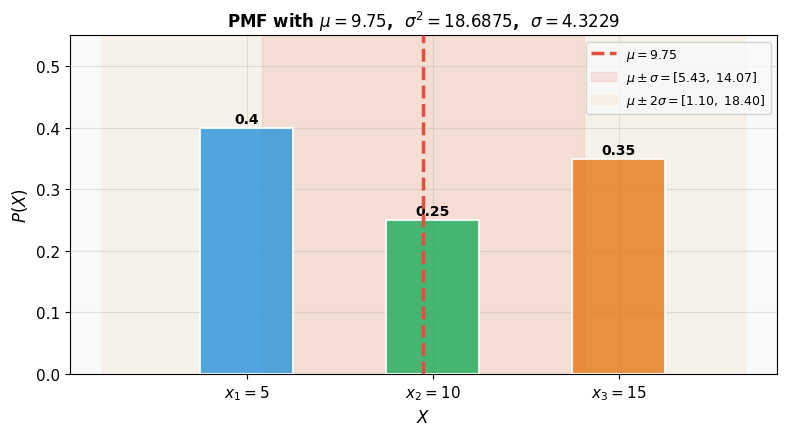

In [3]:
# --- PMF with mean ± std shading ---
fig, ax = plt.subplots(figsize=(8, 4.5))

bar_colors = ['#3498db', '#27ae60', '#e67e22']
ax.bar(values, probs, width=2.5, color=bar_colors, edgecolor='white', linewidth=1.5,
       alpha=0.85, zorder=3)

# μ line
ax.axvline(mu, color='#e74c3c', lw=2.5, ls='--', zorder=4, label=f'$\\mu = {mu}$')

# μ ± σ band
ax.axvspan(mu - std_X, mu + std_X, alpha=0.12, color='#e74c3c',
           label=f'$\\mu \\pm \\sigma = [{mu-std_X:.2f},\\ {mu+std_X:.2f}]$')

# μ ± 2σ band
ax.axvspan(mu - 2*std_X, mu + 2*std_X, alpha=0.07, color='#f39c12',
           label=f'$\\mu \\pm 2\\sigma = [{mu-2*std_X:.2f},\\ {mu+2*std_X:.2f}]$')

# bar labels
for xi, pi in zip(values, probs):
    ax.text(xi, pi + 0.008, f'{pi}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(values)
ax.set_xticklabels([f'$x_{i+1}={v}$' for i, v in enumerate(values)], fontsize=11)
ax.set_xlabel('$X$', fontsize=12)
ax.set_ylabel('$P(X)$', fontsize=12)
ax.set_title(f'PMF with $\\mu={mu}$,  $\\sigma^2={var_X:.4f}$,  $\\sigma={std_X:.4f}$',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.55)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Alternative Formula — Computing Variance via $E[X^2]$

The variance can also be computed as:

$$\sigma^2 = E[X^2] - (E[X])^2 = E[X^2] - \mu^2$$

where $E[X^2] = \sum_X X^2\, P(X)$.

This is often easier to compute by hand.

In [4]:
# --- Verify both formulas give the same result ---
E_X2   = np.sum(probs * values**2)
var_v2 = E_X2 - mu**2

print(f"Method 1 — Direct:   σ² = Σ(xᵢ-μ)²·P(xᵢ) = {var_X:.6f}")
print(f"Method 2 — E[X²]-μ²: σ² = E[X²] - μ²")
print(f"           E[X²] = Σ xᵢ²·P(xᵢ) = {E_X2:.4f}")
print(f"           μ²    = {mu}² = {mu**2:.4f}")
print(f"           σ²    = {E_X2:.4f} - {mu**2:.4f} = {var_v2:.6f}")
print()
print(f"Both methods agree: {np.isclose(var_X, var_v2)}")

Method 1 — Direct:   σ² = Σ(xᵢ-μ)²·P(xᵢ) = 18.687500
Method 2 — E[X²]-μ²: σ² = E[X²] - μ²
           E[X²] = Σ xᵢ²·P(xᵢ) = 113.7500
           μ²    = 9.75² = 95.0625
           σ²    = 113.7500 - 95.0625 = 18.687500

Both methods agree: True


## Effect of Spread — Low vs High Variance

Two distributions can have the **same mean** but very different variances. Variance captures how *spread out* the values are.

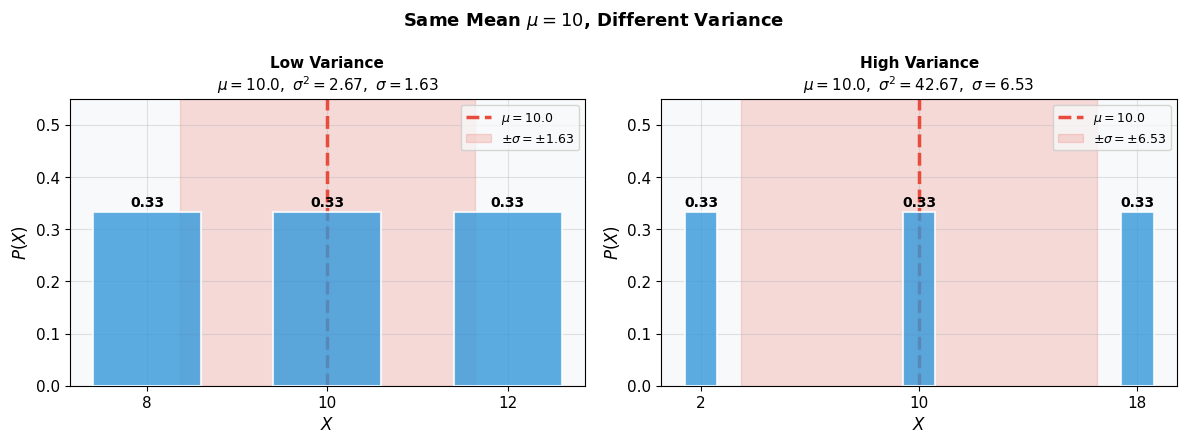

In [5]:
# --- Same mean, different variance ---
# Both distributions have mean = 10
dist_low  = {'values': np.array([8, 10, 12]),    'probs': np.array([1/3, 1/3, 1/3])}
dist_high = {'values': np.array([2, 10, 18]),    'probs': np.array([1/3, 1/3, 1/3])}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

for ax, d, title_tag in zip(axes, [dist_low, dist_high], ['Low', 'High']):
    v, p = d['values'], d['probs']
    m    = np.sum(p * v)
    var  = np.sum(p * (v - m)**2)
    std  = np.sqrt(var)

    ax.bar(v, p, width=1.2, color='#3498db', edgecolor='white', linewidth=1.5,
           alpha=0.8, zorder=3)
    ax.axvline(m,        color='#e74c3c',  lw=2.5, ls='--', label=f'$\\mu = {m:.1f}$')
    ax.axvspan(m - std, m + std, alpha=0.18, color='#e74c3c',
               label=f'$\\pm\\sigma = \\pm{std:.2f}$')

    for xi, pi in zip(v, p):
        ax.text(xi, pi + 0.01, f'{pi:.2f}', ha='center', fontsize=10, fontweight='bold')

    ax.set_xticks(v)
    ax.set_xlabel('$X$', fontsize=12)
    ax.set_ylabel('$P(X)$', fontsize=12)
    ax.set_title(f'{title_tag} Variance\n$\\mu={m:.1f},\\ \\sigma^2={var:.2f},\\ \\sigma={std:.2f}$',
                 fontsize=11, fontweight='bold')
    ax.set_ylim(0, 0.55)
    ax.legend(fontsize=9)

plt.suptitle('Same Mean $\\mu=10$, Different Variance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Variance for Common Discrete Distributions

| Distribution | Parameters | $E[X]$ | $\text{Var}(X)$ |
|---|---|---|---|
| **Bernoulli** | $p$ | $p$ | $p(1-p)$ |
| **Binomial** | $n, p$ | $np$ | $np(1-p)$ |
| **Geometric** | $p$ | $1/p$ | $(1-p)/p^2$ |
| **Poisson** | $\lambda$ | $\lambda$ | $\lambda$ |

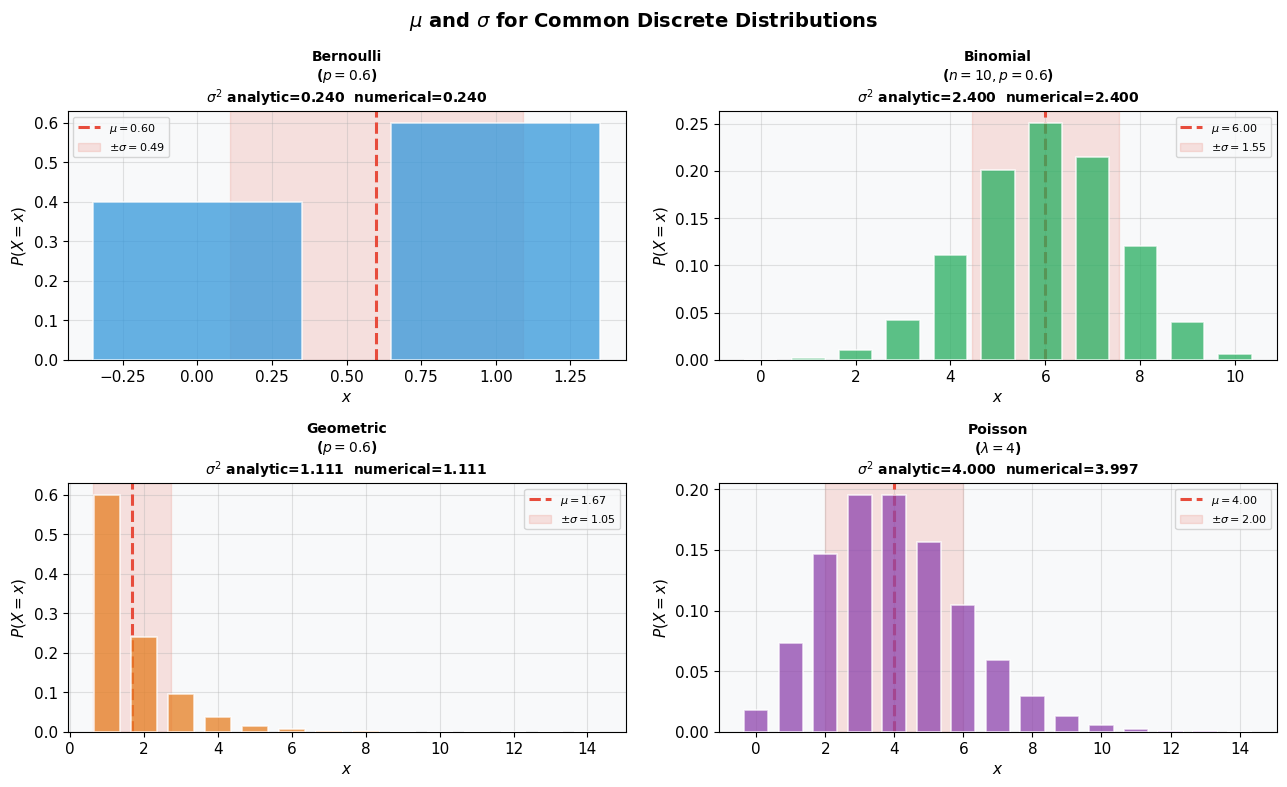

Distribution                 E[X]   Var(X) num   Var(X) analytic
─────────────────────────────────────────────────────────────────
Bernoulli (p=0.6)          0.6000       0.2400            0.2400
Binomial (n=10,p=0.6)      6.0000       2.4000            2.4000
Geometric (p=0.6)          1.6666       1.1106            1.1111
Poisson (λ=4)              3.9997       3.9974            4.0000


In [6]:
from scipy.stats import bernoulli, binom, geom, poisson

p_p, n_p, lam_p = 0.6, 10, 4

distributions = {
    'Bernoulli\n($p=0.6$)':    (bernoulli(p_p),    np.arange(0, 2),     '#3498db',
                                  p_p,          p_p*(1-p_p)),
    'Binomial\n($n=10,p=0.6$)': (binom(n_p, p_p),  np.arange(0, n_p+1), '#27ae60',
                                  n_p*p_p,      n_p*p_p*(1-p_p)),
    'Geometric\n($p=0.6$)':    (geom(p_p),         np.arange(1, 15),    '#e67e22',
                                  1/p_p,        (1-p_p)/p_p**2),
    'Poisson\n($\\lambda=4$)': (poisson(lam_p),    np.arange(0, 15),    '#8e44ad',
                                  lam_p,        lam_p),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('$\\mu$ and $\\sigma$ for Common Discrete Distributions', fontsize=14, fontweight='bold')

for ax, (title, (dist, xs, col, ex_a, var_a)) in zip(axes.flat, distributions.items()):
    pmf     = dist.pmf(xs)
    E_num   = np.sum(pmf * xs)
    var_num = np.sum(pmf * (xs - E_num)**2)
    std_num = np.sqrt(var_num)

    ax.bar(xs, pmf, color=col, alpha=0.75, edgecolor='white', linewidth=1.2, width=0.7, zorder=3)
    ax.axvline(E_num, color='#e74c3c', lw=2.2, ls='--',
               label=f'$\\mu={E_num:.2f}$')
    ax.axvspan(E_num - std_num, E_num + std_num, alpha=0.15, color='#e74c3c',
               label=f'$\\pm\\sigma={std_num:.2f}$')
    ax.set_title(f'{title}\n$\\sigma^2$ analytic={var_a:.3f}  numerical={var_num:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('$x$'); ax.set_ylabel('$P(X=x)$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'Distribution':<24} {'E[X]':>8} {'Var(X) num':>12} {'Var(X) analytic':>17}")
print("─" * 65)
for title, (dist, xs, col, ex_a, var_a) in distributions.items():
    pmf     = dist.pmf(xs)
    E_num   = np.sum(pmf * xs)
    var_num = np.sum(pmf * (xs - E_num)**2)
    name    = title.replace('\n', ' ').replace('$', '').replace('\\lambda=4', 'λ=4')
    print(f"{name:<24} {E_num:>8.4f} {var_num:>12.4f} {var_a:>17.4f}")

## Summary

| Quantity | Formula | Interpretation |
|---|---|---|
| **Variance** | $\sigma^2 = E[(X-\mu)^2] = \sum (x_i-\mu)^2 P(x_i)$ | Spread of $X$ around $\mu$ (squared units) |
| **Alt. formula** | $\sigma^2 = E[X^2] - \mu^2$ | Easier to compute by hand |
| **Std deviation** | $\sigma = \sqrt{\sigma^2}$ | Spread in the same units as $X$ |
| **Statistical order** | 1st moment = $E[X]$; 2nd moment = $E[X^2]$ | Variance uses the 2nd moment |

> A small $\sigma$ means values are tightly clustered around $\mu$; a large $\sigma$ means they are widely spread. The sign of deviations cancels in $E[X-\mu]$, which is why we square them.